In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
breast_cancer_df=pd.read_csv("../data/breast_cancer.csv")

In [81]:
print(breast_cancer_df.index)
print(breast_cancer_df.head(20))

RangeIndex(start=0, stop=569, step=1)
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0     842302         R        17.99         10.38          122.80     1001.0   
1     842517         R        20.57         17.77          132.90     1326.0   
2   84300903         R        19.69         21.25          130.00     1203.0   
3   84348301         R        11.42         20.38           77.58      386.1   
4   84358402         R        20.29         14.34          135.10     1297.0   
5     843786         R        12.45         15.70           82.57      477.1   
6     844359         R        18.25         19.98          119.60     1040.0   
7   84458202         R        13.71         20.83           90.20      577.9   
8     844981         R        13.00         21.82           87.50      519.8   
9   84501001         R        12.46         24.04           83.97      475.9   
10    845636         R        16.02         23.24          102.70      797.8   
11

In [82]:
print(breast_cancer_df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [83]:
print(breast_cancer_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [84]:
print(breast_cancer_df.isna().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [85]:
print(breast_cancer_df["diagnosis"].value_counts())

diagnosis
N    357
R    212
Name: count, dtype: int64


In [86]:
breast_cancer_df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


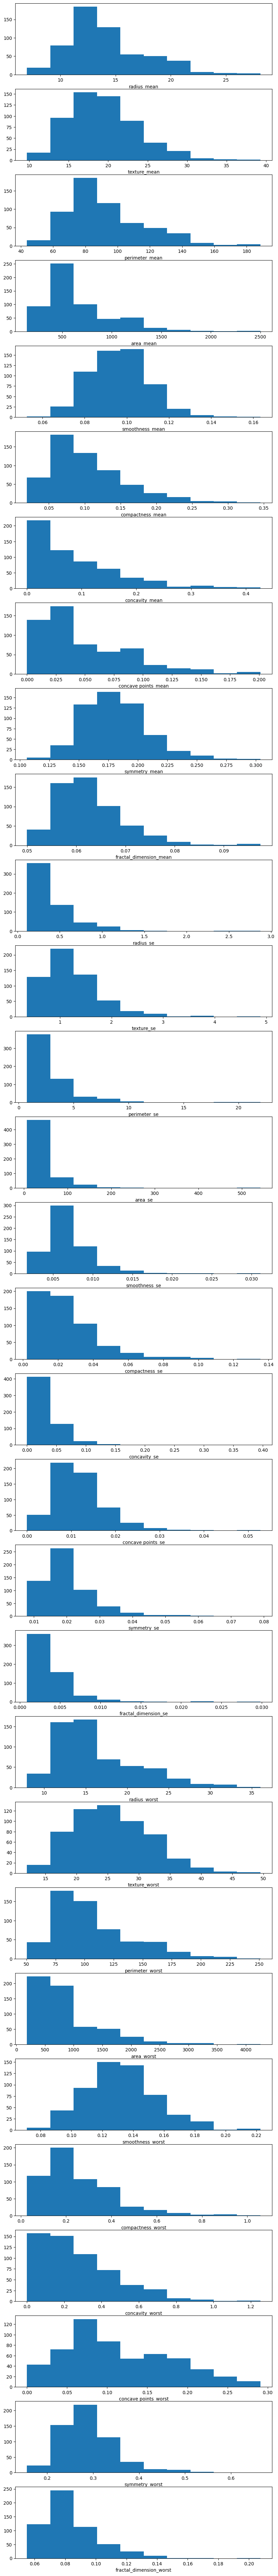

In [87]:
features=breast_cancer_df.columns[2:]
fig,ax=plt.subplots(len(features),1)
for col in range(0,len(features)):
    ax[col].hist(breast_cancer_df[features[col]])
    ax[col].set_xlabel(features[col])
fig.set_size_inches([10,100])
plt.show()

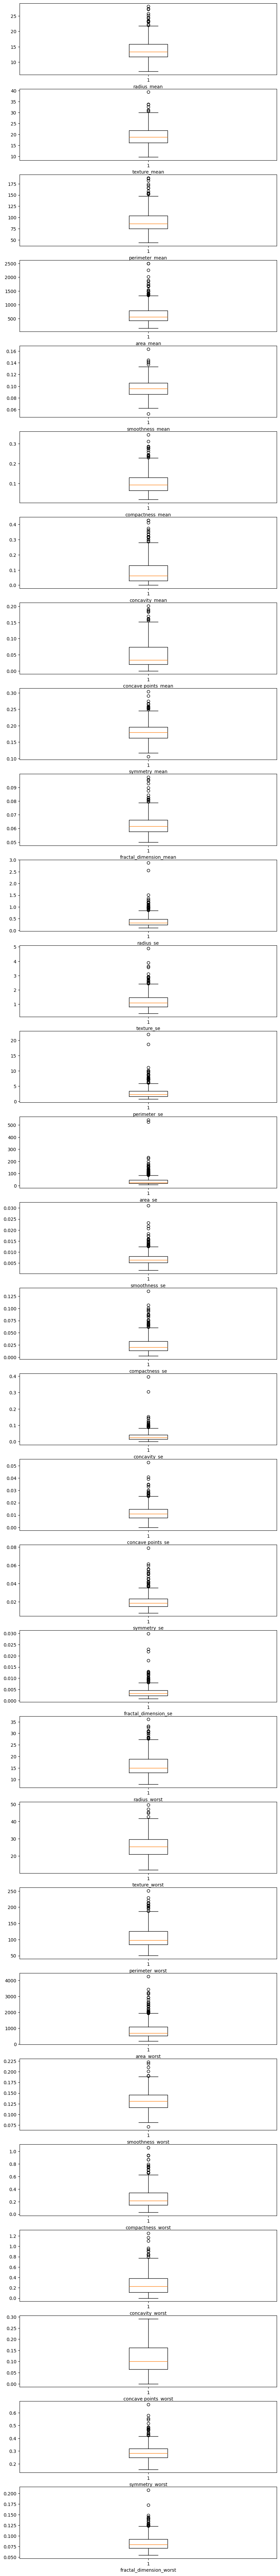

In [88]:
fig , ax = plt.subplots(len(features),1)
for col in range(0,len(features)):
    ax[col].boxplot(breast_cancer_df[features[col]])
    ax[col].set_xlabel(features[col])
fig.set_size_inches([10,100])
plt.show()

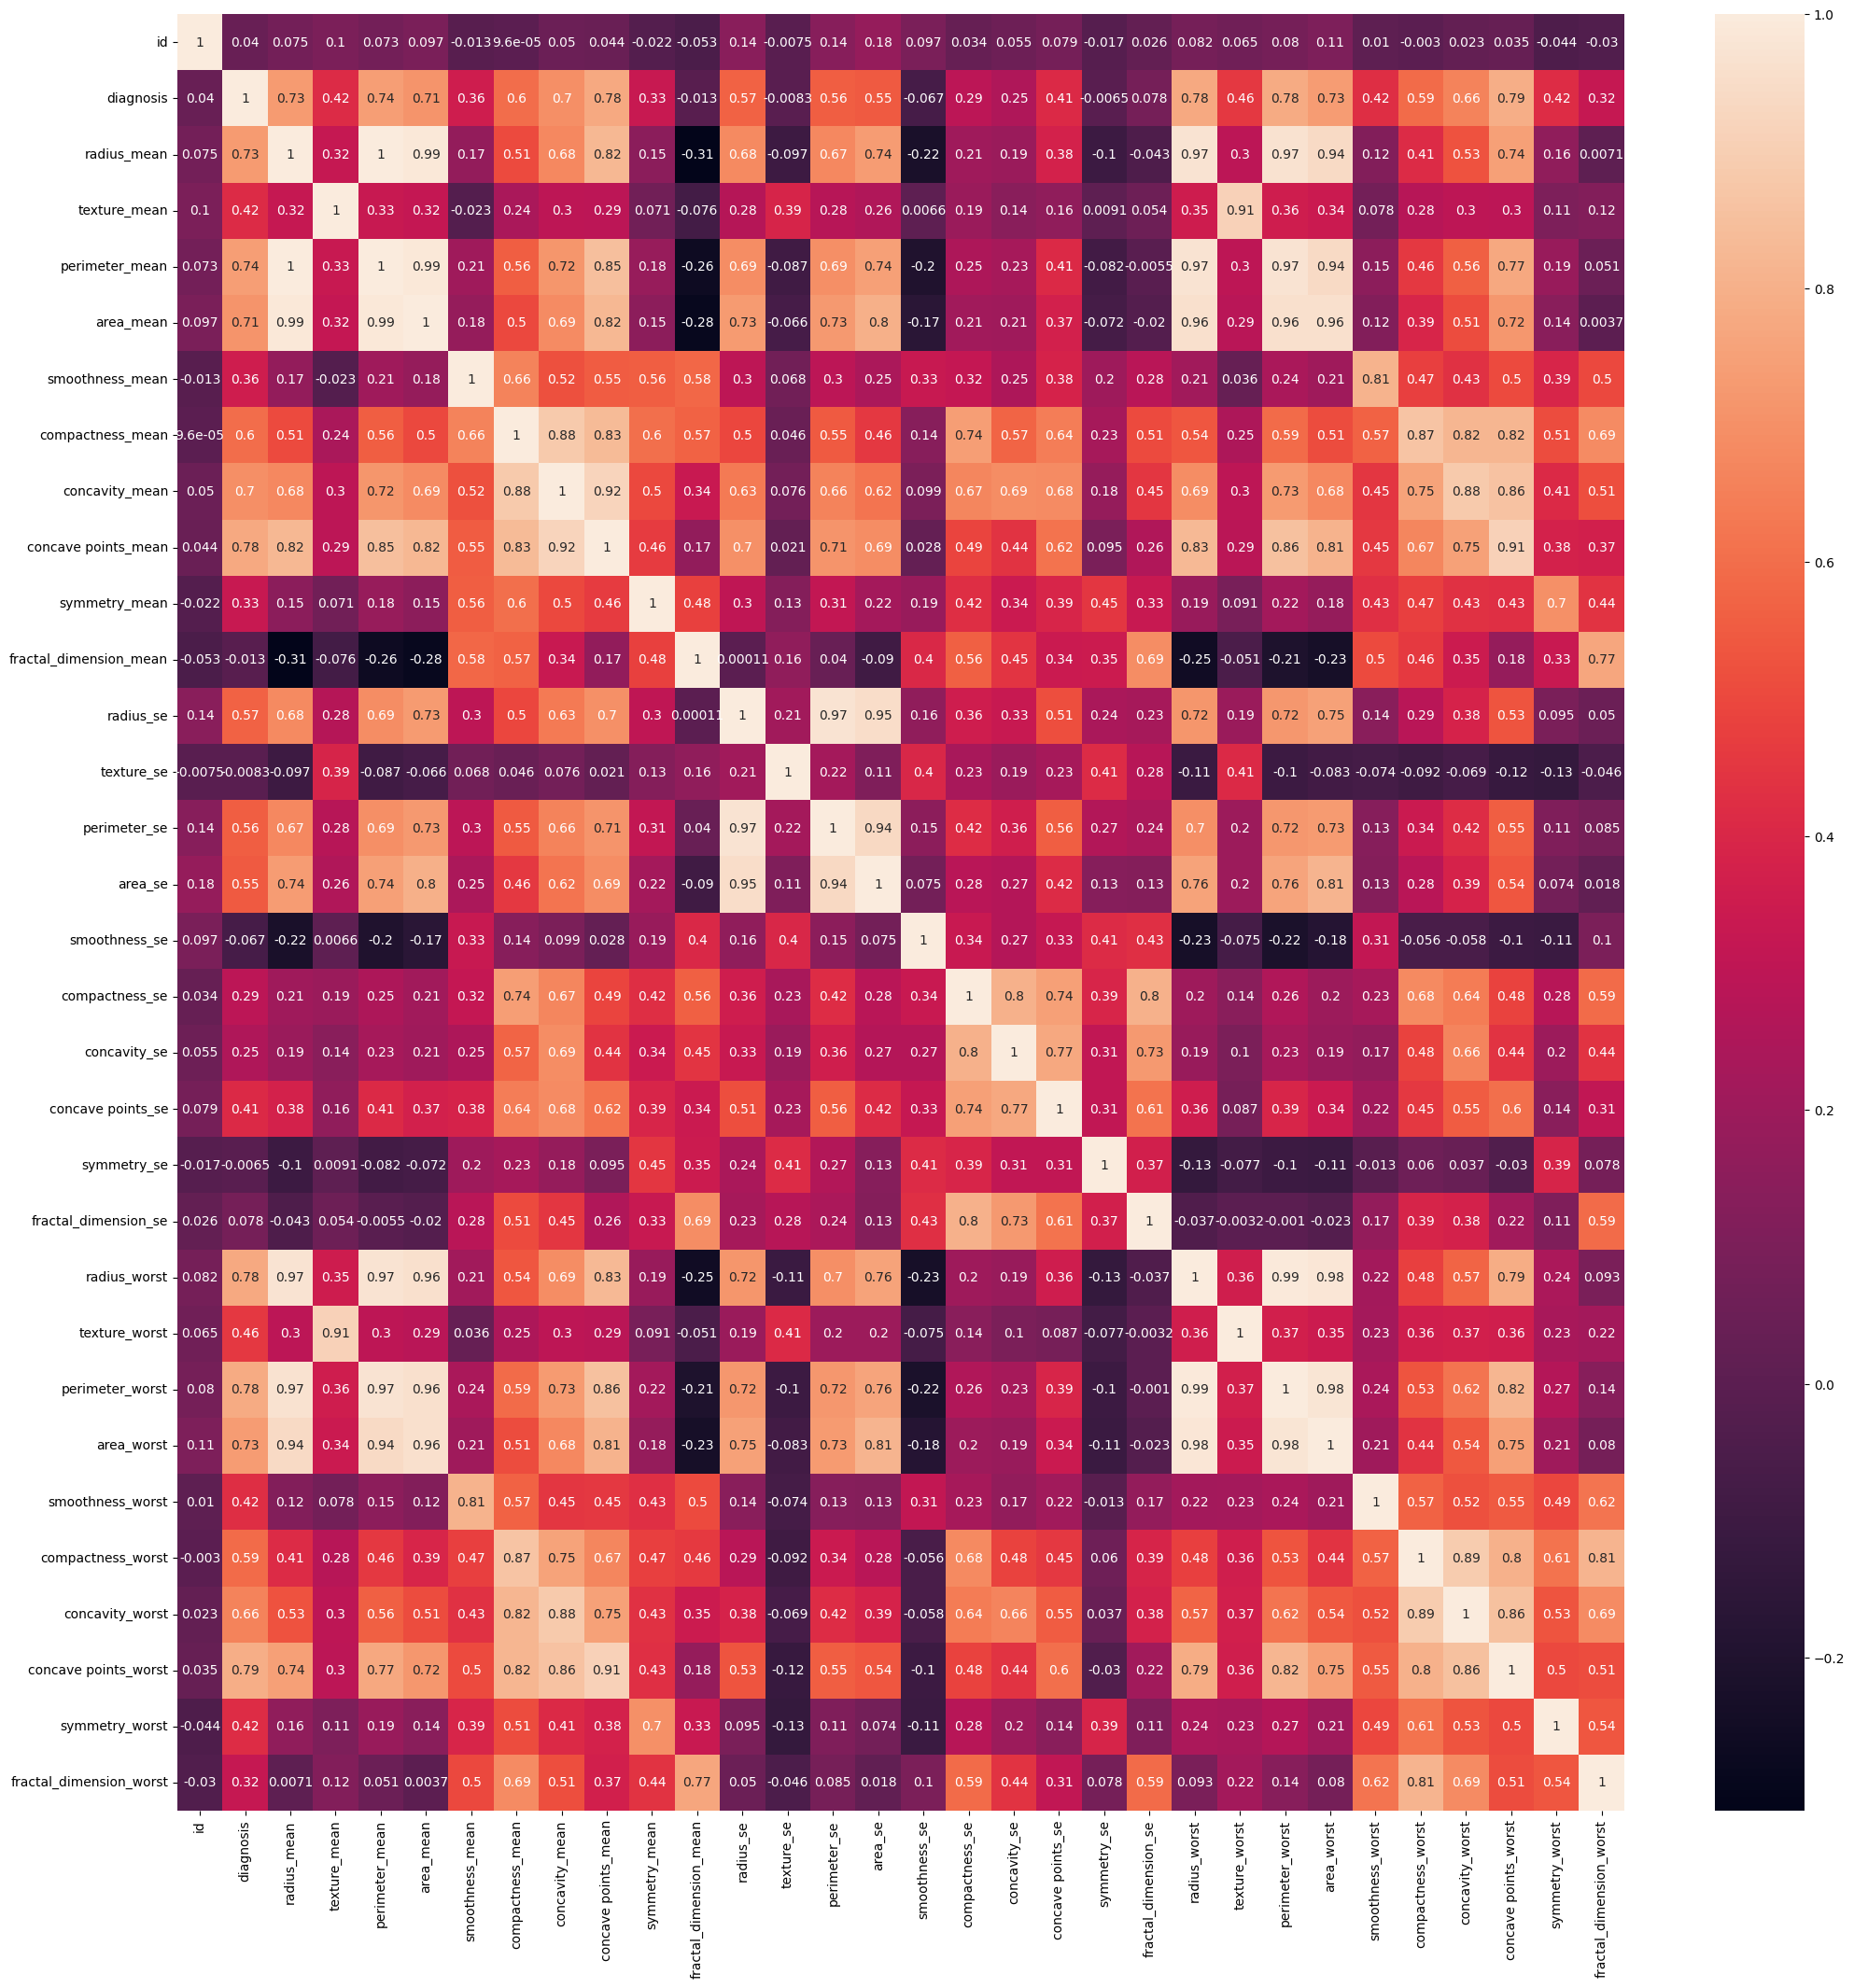

In [90]:
breast_cancer_df["diagnosis"]=breast_cancer_df["diagnosis"].map({'R':1,'N':0})
plt.figure(figsize=(25, 25))
sns.heatmap(breast_cancer_df.corr(),annot=True)
plt.show()

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [92]:
X=breast_cancer_df.drop(["diagnosis","id"],axis=1).values
y=breast_cancer_df["diagnosis"].values
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [93]:
steps=[("scaling",StandardScaler()),
        ("logistic_regression",LogisticRegression())]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/cancer/cancer_logistic_regression_report.csv")

In [ ]:
import os
__file__="DiseasePrediction"
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
data=model_file = os.path.join(BASE_DIR, "models", "cancer_pipline.pkl")

In [97]:
import joblib
joblib.dump(pipeline,'../models/cancer_pipline.pkl')

['../models/cancer_pipline.pkl']

In [94]:
steps=[("scaling",StandardScaler()),
        ("svm",SVC(kernel='rbf'))]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/cancer/cancer_SVM_report.csv")

In [95]:
steps=[("scaling",StandardScaler()),
        ("random_forest",RandomForestClassifier(n_estimators=10,random_state=42))]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/cancer/cancer_RandomForest_report.csv")

In [96]:
steps=[("scaling",StandardScaler()),
        ("xgboost",XGBClassifier(n_estimators=10))]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/cancer/cancer_xgboost_report.csv")